In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive

drive.mount("/content/drive")
%cd /content/drive/MyDrive/MA/data
sales_data = pd.read_csv("sales_data_updated.csv")
sales_data.head()

Mounted at /content/drive
/content/drive/MyDrive/MA/data


,order_date,time,aging,customer_id,gender,device_type,customer_login_type,product_category,product,sales,quantity,discount,profit,shipping_cost,order_priority,payment_method
0,2018-01-01,10:11:40,5.0,29317,Male,Web,Member,Auto & Accessories,Car Media Players,140.0,4.0,0.3,43.2,4.3,Medium,e_wallet
1,2018-01-01,22:30:44,7.0,42270,Male,Web,Member,Auto & Accessories,Car Pillow & Neck Rest,231.0,5.0,0.1,139.5,13.9,High,money_order
2,2018-01-01,21:55:31,10.0,14563,Male,Web,Member,Auto & Accessories,Car Speakers,211.0,5.0,0.1,120.5,12.0,High,credit_card
3,2018-01-01,13:57:15,9.0,58601,Male,Web,Member,Auto & Accessories,Tyre,250.0,4.0,0.2,150.0,15.0,Critical,credit_card
4,2018-01-01,15:17:41,2.0,48342,Male,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.1,165.0,16.5,High,credit_card


In [4]:
sales_data = sales_data.dropna()
sales_data.describe()

,aging,customer_id,sales,quantity,discount,profit,shipping_cost
count,51282.000000,51282.000000,51282.000000,51282.000000,51282.000000,51282.000000,51282.000000
mean,5.255187,58159.746656,152.337350,2.502964,0.303838,70.401796,7.041166
std,2.960073,26031.763189,66.492468,1.511834,0.131025,48.728131,4.871685
min,1.000000,10000.000000,33.000000,1.000000,0.100000,0.500000,0.100000
25%,3.000000,35841.500000,85.000000,1.000000,0.200000,24.900000,2.500000
50%,5.000000,61021.500000,133.000000,2.000000,0.300000,59.900000,6.000000
75%,8.000000,80739.250000,218.000000,4.000000,0.400000,118.400000,11.800000
max,10.500000,99999.000000,250.000000,5.000000,0.500000,167.500000,16.800000


# Побудуй гістограму для візуалізації розподілу прибутку (profit). Проаналізуй, який характер розподілу значень загалом, які значення переважають.

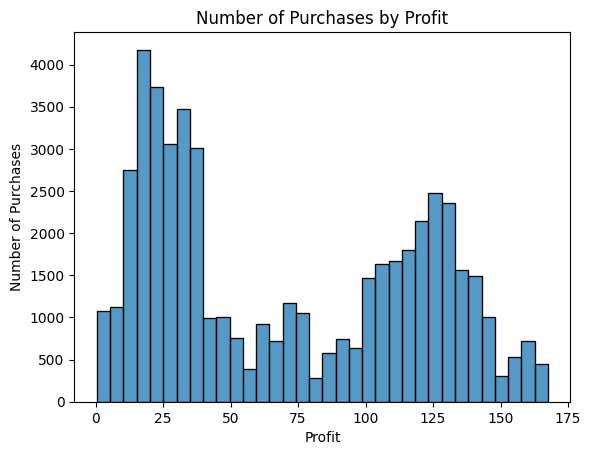

In [5]:
sns.histplot(data=sales_data, x="profit")
plt.title("Number of Purchases by Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Purchases")
plt.show()

- Два виражені піки: перший — у діапазоні прибутку 15-40, другий — у діапазоні 100–140.

- Розподіл не є рівномірним: між піками кількість покупок значно менша, що створює «провали» в частоті.

- Правий хвіст — після 140 прибуток зустрічається рідше, але все ж є окремі випадки.

Найчастіше зустрічаються покупки з невеликим прибутком (15–40) — це може бути масовий сегмент товарів. Другий кластер (100–140) свідчить про іншу групу товарів/послуг, які приносять більший прибуток, але продаються рідше. Загалом розподіл має мультимодальний характер, що вказує на різні типи продуктів або цінових стратегій у даних.

# Побудуй окремо гістограми прибутку для продажів через веббраузер та мобільний додаток (device_type). Зроби це на одній візуалізації (використай параметр hue) та на окремих (параметр col). Скористайся Google або ChatGPT для того, щоб дізнатися як працює параметр col.

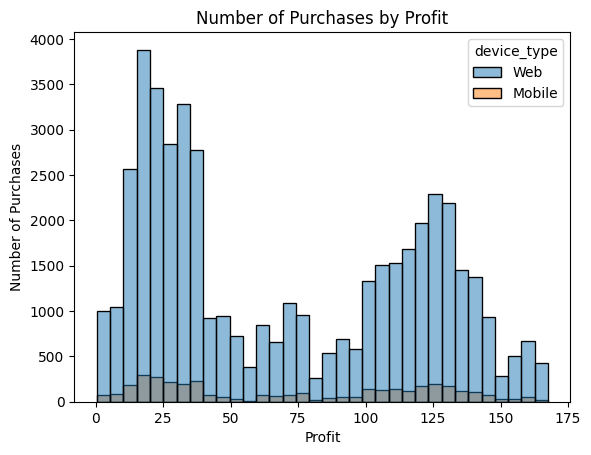

In [6]:
sns.histplot(
    data=sales_data,
    x="profit",
    hue="device_type"
)
plt.title("Number of Purchases by Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Purchases")
plt.show()

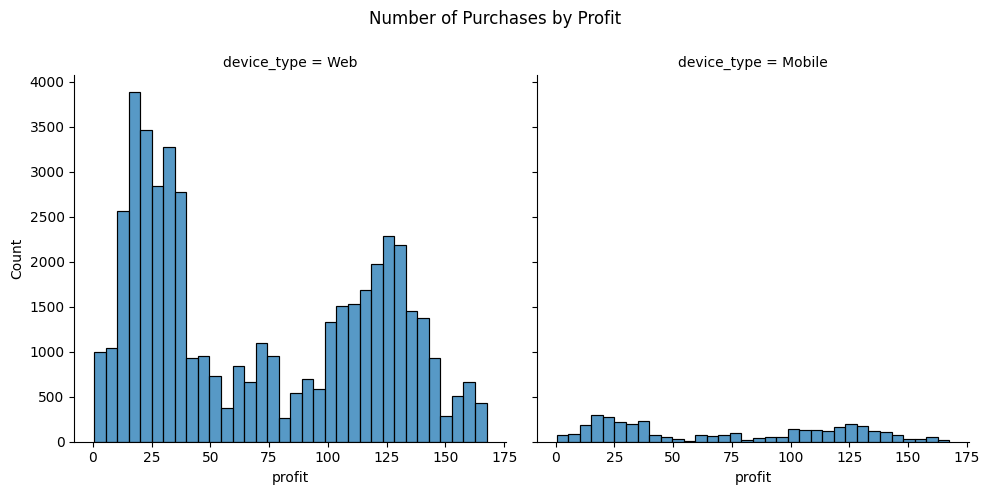

In [7]:
sns.displot(
    data=sales_data,
    x="profit",
    col="device_type"
)
plt.subplots_adjust(top=0.85)
plt.suptitle("Number of Purchases by Profit")
plt.show()

# Створи лінійний графік, який показує зміну прибутків (profit) у часі (order_date). Перед цим потрібно переконатись у тому, що колонка order_date має відповідний тип даних. Це допоможе зрозуміти тенденцію покупок протягом зазначеного періоду. Якою є ця тенденція згідно з графіком? Запиши відповідь у текстовому полі.

In [8]:
sales_data["order_date"] = pd.to_datetime(sales_data["order_date"], format="%Y-%m-%d")

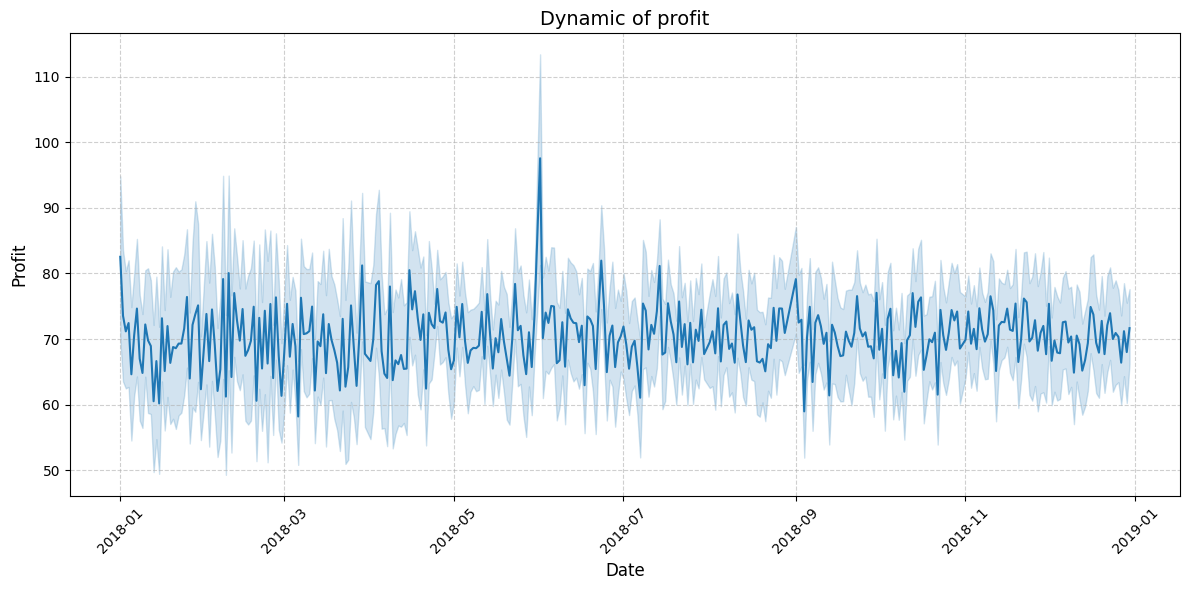

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=sales_data,
    x="order_date",
    y="profit"
)

plt.title("Dynamic of profit", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Profit", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Якою є ця тенденція згідно з графіком?

- Загальний рівень прибутку коливається навколо 70, без чітко вираженого довгострокового зростання чи падіння.
- Волатильність: є регулярні коливання вгору-вниз, що свідчить про нестабільність у щоденних продажах.
- Помітний сплеск у середині 2018 року — різке підвищення прибутку, яке виділяється на фоні загальної динаміки.

Тенденція: стабільні коливання навколо середнього значення, з окремими аномаліями.

# Побудуй стовпчастий графік, що показує загальний прибуток за категоріями товарів (product_category). Яка категорія найбільш прибуткова? Яка найменш прибуткова? Запиши відповідь у текстовому полі.

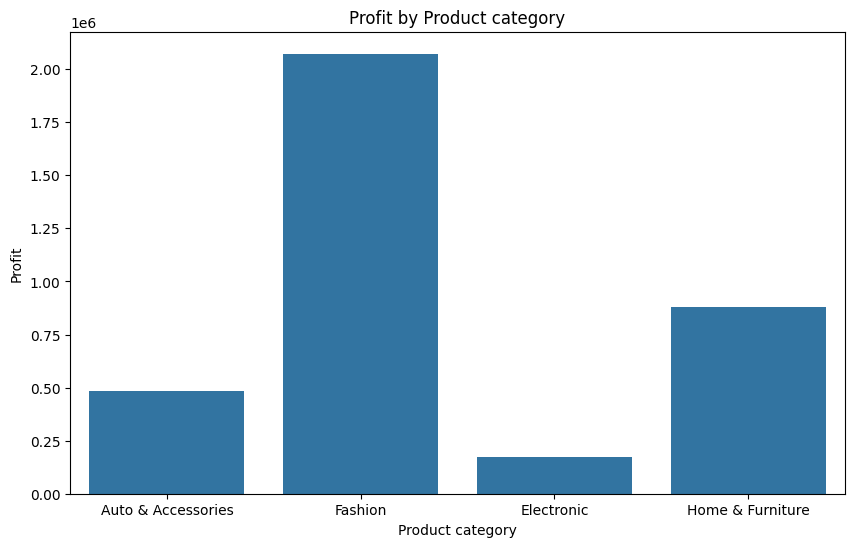

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=sales_data,
    x="product_category",
    y="profit",
    estimator=sum,
    errorbar=("ci", False)
)
plt.title("Profit by Product category")
plt.xlabel("Product category")
plt.ylabel("Profit")
plt.show()

Яка категорія найбільш прибуткова? Fashion

Яка найменш прибуткова? Electronic

# Використай параметр hue та стовпчик gender, щоб подивитись на загальні прибутки за категоріями у розрізі клієнтів-чоловіків та клієнтів-жінок. Які висновки можна зробити? Чи є відмінності у поведінці між двома групами клієнтів? Запиши відповідь у текстовому полі.

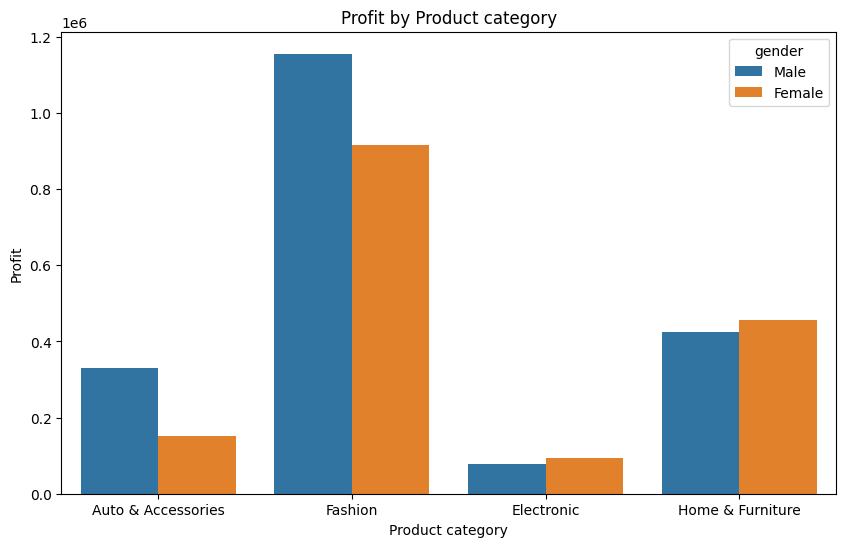

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=sales_data,
    x="product_category",
    y="profit",
    hue="gender",
    estimator=sum,
    errorbar=("ci", False)
)
plt.title("Profit by Product category")
plt.xlabel("Product category")
plt.ylabel("Profit")
plt.show()

Які висновки можна зробити? Чи є відмінності у поведінці між двома групами клієнтів?

Є певні відмінності у поведінці: чоловіки більше витрачають у категоріях, пов’язаних з авто та модою, тоді як жінки — у електроніці та товарах для дому.
Водночас загальна картина показує, що різниця не є радикальною — у кожній категорії обидві групи активно присутні.